In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor

In [2]:
import shap

/Users/rv/opt/anaconda3/envs/testing_env/lib/python3.9/site-packages/shap/utils/_clustering.py:35: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def _pt_shuffle_rec(i, indexes, index_mask, partition_tree, M, pos):
/Users/rv/opt/anaconda3/envs/testing_env/lib/python3.9/site-packages/shap/utils/_clustering.py:54: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def d

## Dataset

In [3]:
data = pd.read_csv("interaction_dataset.csv",sep='\t')

y = data['bonus']
X = data.drop('bonus', axis=1)

print(len(data))
data.head()

1000


,experience,degree,performance,sales,days_late,bonus
0,31,1,6.11,29,14,197
1,35,1,9.55,44,8,314
2,9,1,2.64,26,20,88
3,40,1,0.22,13,7,233
4,18,1,6.46,11,13,108


## Modelling

In [4]:
#Train model
model = RandomForestRegressor(n_estimators=100) 
model.fit(X, y)

#Get predictions
y_pred = model.predict(X)

Text(0.5, 0, 'Actual')

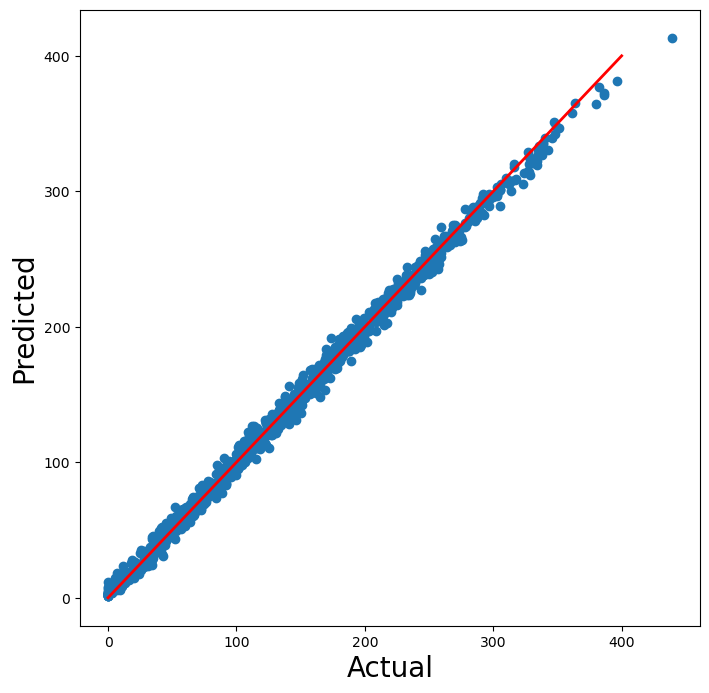

In [5]:
#Model evaluation
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 8))

plt.scatter(y, y_pred)
plt.plot([0, 400], [0, 400], color='r', linestyle='-', linewidth=2)

plt.ylabel('Predicted', size=20)
plt.xlabel('Actual', size=20)

## Standard SHAP  values

In [6]:
#Get SHAP values
explainer = shap.Explainer(model)
shap_values = explainer(X)

# Which features do NOT have a significant relationship with bonus?

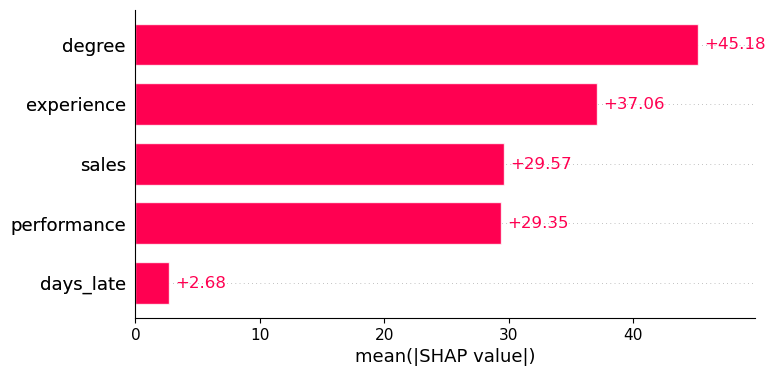

In [7]:
shap.plots.bar(shap_values)

# What tends to happens to an employee's bonus as they gain more experience? 

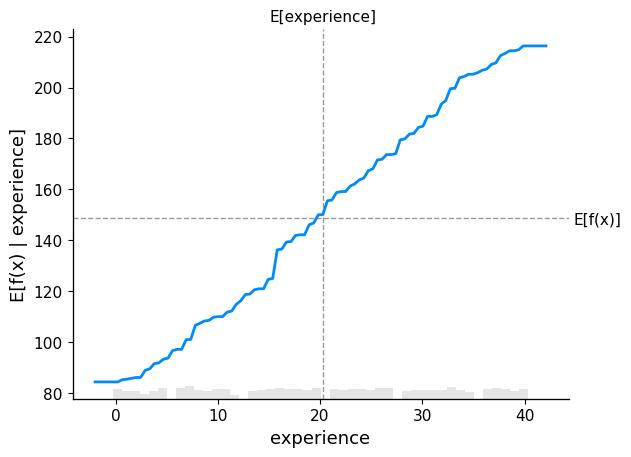

In [8]:
shap.partial_dependence_plot(
    "experience",
    model.predict,
    X,
    ice=False,
    model_expected_value=True,
    feature_expected_value=True
)

Bonus increases with experience

## SHAP interaction values

In [9]:
#Get SHAP interaction values
explainer = shap.Explainer(model)
shap_interaction = explainer.shap_interaction_values(X)

# Are there any potential interactions in the dataset? 

In [10]:
shap_interaction.shape

(1000, 5, 5)

In [11]:
mean_shap = np.abs(shap_interaction).mean(0)
df = pd.DataFrame(mean_shap, index=X.columns, columns=X.columns)
df

,experience,degree,performance,sales,days_late
experience,37.424858,9.669146,1.541886,1.440009,0.416211
degree,9.669146,44.509178,0.933381,0.942547,0.234271
performance,1.541886,0.933381,29.621650,6.395081,0.399276
sales,1.440009,0.942547,6.395081,30.116505,0.348711
days_late,0.416211,0.234271,0.399276,0.348711,2.744593


In [12]:
df.where(df.values == np.diagonal(df),df.values*2)

,experience,degree,performance,sales,days_late
experience,37.424858,19.338292,3.083771,2.880018,0.832421
degree,19.338292,44.509178,1.866763,1.885095,0.468542
performance,3.083771,1.866763,29.621650,12.790163,0.798553
sales,2.880018,1.885095,12.790163,30.116505,0.697422
days_late,0.832421,0.468542,0.798553,0.697422,2.744593


(array([0.5, 1.5, 2.5, 3.5, 4.5]),
 [Text(0, 0.5, 'experience'),
  Text(0, 1.5, 'degree'),
  Text(0, 2.5, 'performance'),
  Text(0, 3.5, 'sales'),
  Text(0, 4.5, 'days_late')])

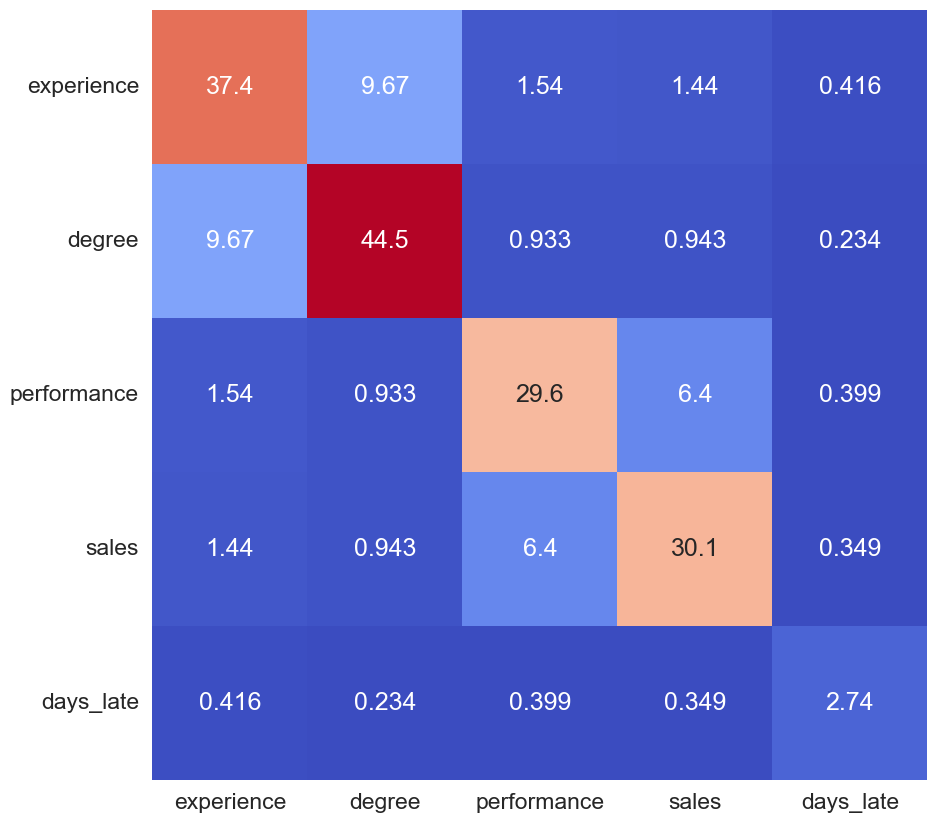

In [13]:
plt.figure(figsize=(10, 10), facecolor='w', edgecolor='k')
sns.set(font_scale=1.5)
sns.heatmap(df,cmap='coolwarm',annot=True,fmt='.3g',cbar=False)
plt.yticks(rotation=0) 

Yes, degree.experience and sales.performance

---